# Application B — Advertising, multiple features, and interactions

**Purpose:** Predict sales from advertising budgets, compare several linear regression
models, and understand why allowing TV and radio to act together can improve predictions.

`Advertising.csv`, loaded from the official textbook website, contains 200 markets.
Each row describes one market. The inputs (also called **features**) are the advertising
budgets `TV`, `radio`, and `newspaper`, measured in thousands of dollars. The target
`sales` is measured in thousands of units sold.
For example, `TV = 100` means a TV budget of \$100,000, and `sales = 12` means 12,000 units sold.
The first CSV column is a row index, not a feature. The units are described in Chapter 3
of the bundled *An Introduction to Statistical Learning*, second edition.

**Cross-validation (CV)** means repeatedly fitting a model on part of the training data
and evaluating its predictions on the remaining part. Here, **five-fold cross-validation**
divides the training rows into five groups called *folds*. Each group takes a turn being
held out for scoring. We use the resulting prediction errors to choose among four models.
Section 2 walks through the procedure.

**Root mean squared error (RMSE)** summarizes prediction error; smaller is better.
It is expressed in the same units as sales. Section 2 gives its formula.
Section 5 also introduces mean absolute error (MAE) and the coefficient of determination ($R^2$).

### What happens in this notebook?

1. **Reserve separate data:** 120 markets for training, 40 for validation, and 40 for the final test.
2. **Choose a model:** use cross-validation within the 120 training markets to compare a constant
   prediction, TV alone, an additive model, and a TV/radio interaction model.
3. **Interpret the fitted relationship:** calculate how a TV budget increase changes the
   predicted sales at two different radio budgets.
4. **Check the fit:** examine training prediction errors and check the chosen model on validation data.
5. **Evaluate once on the test data:** compare the chosen model with a simple constant prediction.

The three data sets have different roles. Training data are used to fit and choose models.
The separate validation data provide an additional check; in this exercise they do not change
the selected model. Test data are kept until Section 5 to assess predictions on unseen markets.
The split uses `random_state=23` so rerunning the notebook gives the same partitions.

### Model notation and Python objects

$y$ denotes observed sales, $\hat y$ predicted sales, $b$ the intercept, and $w_j$ the
coefficient multiplying feature $j$. The intercept and coefficients are learned from data.
`LinearRegression()` creates a model object. Calling `.fit(X, y)` learns these parameters
from an input table `X` and a target vector `y`; `.predict(X_new)` then predicts sales for
new rows without learning new parameters. After fitting, `.intercept_` contains $b$ and
`.coef_` contains the coefficients in the order of the input columns.

Run locally or in Google Colab with an internet connection; no dataset upload or course
folder is needed. The code uses NumPy, pandas, Matplotlib, and scikit-learn.
Local dependencies are listed in `../requirements.txt`.
See [the focused guide](01_linear_and_logistic_regression.pdf) when using the course folder.

## 1. Load the data from its URL and reserve the splits

Download the small CSV directly from the [official textbook website](https://www.statlearning.com/resources-second-edition).
The network timeout is 20 seconds: if the server stops responding, the cell raises an
error rather than waiting indefinitely. If that happens, check your connection and rerun the cell.

Read the first column as the row index, so it is not used as a feature.
Check the expected columns, missing values, and partition separation before plotting training targets.

Rows: {'train': 120, 'validation': 40, 'test': 40}


,TV,radio,newspaper,sales,TV_radio
111,225.8,8.2,56.5,13.4,1851.56
185,253.8,21.3,30.0,17.6,5405.94
35,95.7,1.4,7.4,9.5,133.98
195,149.7,35.6,6.0,17.3,5329.32
112,241.7,38.0,23.2,21.8,9184.60


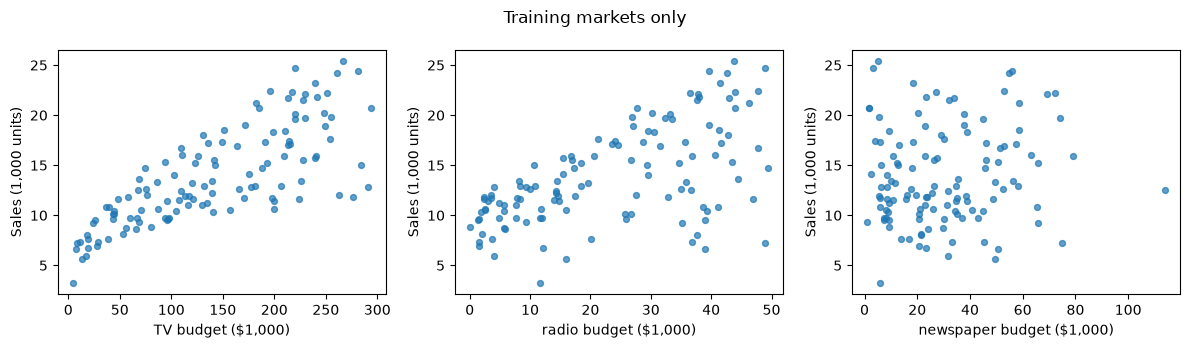

In [1]:
from urllib.request import urlopen
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

url = "https://www.statlearning.com/s/Advertising.csv"
with urlopen(url, timeout=20) as response:
    data = pd.read_csv(response, index_col=0)
assert data.shape == (200, 4)
assert list(data.columns) == ["TV", "radio", "newspaper", "sales"]
assert data.index.is_unique and data.notna().all().all()

# This fixed product learns no parameters from any rows.
data["TV_radio"] = data["TV"] * data["radio"]
train_valid, test = train_test_split(data, test_size=0.20, random_state=23)
train, valid = train_test_split(train_valid, test_size=0.25, random_state=23)
assert set(train.index).isdisjoint(valid.index)
assert set(train.index).isdisjoint(test.index)
assert set(valid.index).isdisjoint(test.index)
print("Rows:", {"train": len(train), "validation": len(valid), "test": len(test)})
display(train.head())

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, feature in zip(axes, ["TV", "radio", "newspaper"]):
    ax.scatter(train[feature], train["sales"], s=18, alpha=0.7)
    ax.set(xlabel=f"{feature} budget ($1,000)", ylabel="Sales (1,000 units)")
fig.suptitle("Training markets only")
plt.tight_layout()
plt.show()

## 2. Compare four models using five-fold cross-validation

**Task:** Decide which of four prediction rules works best on held-out training rows.
We specify the candidates before looking at validation or test performance.

### What are the four candidates?

For compact notation, let $T$, $R$, and $N$ denote the TV, radio, and newspaper budgets
of a market, respectively. Each candidate learns its own parameters.

| Candidate in the code | Prediction rule | What it can represent |
| --- | --- | --- |
| `Mean baseline` | $\hat y=\bar y_{\mathrm{fit}}$ | The same predicted sales for every market; it ignores all budgets. |
| `TV only` | $\hat y=b+w_T T$ | A straight-line relationship between TV spending and sales. |
| `Additive` | $\hat y=b+w_T T+w_R R+w_N N$ | A separate contribution from each budget; the TV slope is the same at every radio budget. |
| `TV-radio interaction` | $\hat y=b+w_T T+w_R R+w_{TR}TR$ | The TV slope can change with the radio budget, and vice versa. |

An **interaction** is a product feature: `TV_radio = TV * radio`. For example,
`TV = 100` and `radio = 20` produce `TV_radio = 2000`. We retain both individual
features as well as their product. This is still linear regression because the
prediction is linear in the learned coefficients $b,w_T,w_R,w_{TR}$, even though
one input column is a product of two original inputs.

The interaction candidate omits newspaper, whereas the additive candidate includes it.
Thus this comparison chooses between two different feature sets; it does not isolate
the effect of adding only the product term to an otherwise identical model.

### How does cross-validation choose a candidate?

Scoring a model only on the rows used to fit it can make its performance look too good.
Cross-validation scores each prediction on a row that was excluded from that particular fit:

1. Shuffle the **120 training rows** reproducibly and divide them into five folds of 24 rows.
2. Hold out the first fold. Fit a fresh model on the other **96 rows**, then predict the
   **24 held-out rows** and calculate their RMSE.
3. Repeat with each of the other folds held out in turn. There are five fits and five scores
   per regression candidate. Every training row is scored once.
4. Average those five RMSE scores. Repeat the same procedure for every candidate, using
   the **same folds** so that comparisons use the same held-out markets.
5. Select the candidate with the lowest average score. An exact tie uses the order in the table.

For a held-out fold with $m=24$ rows, the score is

$$\operatorname{RMSE}=\sqrt{\frac{1}{m}\sum_{i=1}^{m}(y_i-\hat y_i)^2}.$$

Here $y_i$ is actual sales and $\hat y_i$ is predicted sales for row $i$. Squaring penalizes
large errors more heavily; taking the square root restores the sales units. An RMSE of
$0.8$ means a root mean squared error of **800 sales units**. The reported cross-validation
score is the arithmetic mean of the five fold RMSE values.

For the mean baseline, each fold predicts the mean sales of its **96 fitting rows**,
not the mean of all 120 training rows. This keeps the held-out targets out of the prediction rule.
The separate 40-row validation set and 40-row test set are not used anywhere in this selection.

### How to read the code and output

- `candidates` maps each model name to its input columns. An empty list means the constant baseline.
- `KFold` supplies row positions: `fit_rows` selects the 96 fitting rows and `score_rows` the 24 scoring rows.
  `.iloc` uses these positions to extract the corresponding rows.
- `.fit(...)` estimates the coefficients using only the fitting rows; `.predict(...)` predicts the scoring rows.
- `CV RMSE (1,000 units)` is the mean of the five errors. `fold SD` is their **standard deviation**,
  describing how much the score varies across folds. It is not a confidence interval.
- `selected_name` stores the winner. “Frozen candidate” means that we now keep this choice fixed.

Finally, the code fits each regression candidate again on **all 120 training rows** and stores
it in `fitted_models`. These fits support the coefficient and residual comparisons below;
the selected one is the model used for validation and test predictions. We do not average
the five sets of fold coefficients. The baseline now uses the mean of all 120 training targets.
No feature standardization is applied, so coefficients retain the original budget units.

**Read the saved result:** the interaction candidate has the smallest cross-validation RMSE
(about $0.811$ thousand units), compared with $1.553$ for the additive model.
This supports choosing it among these candidates; the independent test evaluation still matters.

In [2]:
candidates = {
    "Mean baseline": [],
    "TV only": ["TV"],
    "Additive": ["TV", "radio", "newspaper"],
    "TV-radio interaction": ["TV", "radio", "TV_radio"],
}
folds = list(KFold(n_splits=5, shuffle=True, random_state=23).split(train))
cv_rows = []
for name, columns in candidates.items():
    fold_rmse = []
    for fit_rows, score_rows in folds:
        fit_data = train.iloc[fit_rows]
        score_data = train.iloc[score_rows]
        if columns:
            model = LinearRegression().fit(fit_data[columns], fit_data["sales"])
            prediction = model.predict(score_data[columns])
        else:
            prediction = np.full(len(score_data), fit_data["sales"].mean())
        fold_rmse.append(np.sqrt(mean_squared_error(score_data["sales"], prediction)))
    cv_rows.append({"model": name, "CV RMSE (1,000 units)": np.mean(fold_rmse),
                    "fold SD": np.std(fold_rmse, ddof=1)})
cv_results = pd.DataFrame(cv_rows)
selected_name = cv_results.loc[cv_results["CV RMSE (1,000 units)"].idxmin(), "model"]
display(cv_results.round(4))
print("Frozen candidate:", selected_name)

baseline = train["sales"].mean()
fitted_models = {}
for name, columns in candidates.items():
    if columns:
        fitted_models[name] = LinearRegression().fit(train[columns], train["sales"])

,model,"CV RMSE (1,000 units)",fold SD
0,Mean baseline,4.8636,0.5601
1,TV only,3.1438,0.2716
2,Additive,1.5533,0.3446
3,TV-radio interaction,0.8107,0.2016


Frozen candidate: TV-radio interaction


## 3. Interpret the interaction using units

**Task:** Use the fitted interaction model to explain how the predicted change from more
TV advertising depends on the radio budget. We examine this prespecified model even if
a different candidate were selected in another run.

The fitted model is

$$\hat y(T,R)=b+w_T T+w_R R+w_{TR}TR.$$

`interaction.intercept_` gives $b$. `interaction.coef_` contains $w_T$, $w_R$, and $w_{TR}$
in the column order `TV`, `radio`, `TV_radio`. The code attaches these names to the numbers
so that we can retrieve coefficients without memorizing their positions.

To understand the TV coefficient, hold radio at a fixed budget $R=r$ and regroup:

$$\hat y(T,r)=(b+w_Rr)+(w_T+w_{TR}r)T.$$

At this radio budget the model is a straight line in TV, with slope $w_T+w_{TR}r$.
Increasing $T$ by one means increasing the TV budget by **\$1,000**. Its exact modeled change is

$$\hat y(T+1,r)-\hat y(T,r)=w_T+w_{TR}r.$$

The result is in **thousands of sales units**, so multiply it by 1,000 to express units sold.
For a TV increase of $\Delta T$ (in thousands of dollars), multiply the slope by $\Delta T$ instead.

Using the coefficients in the saved run:

- $b\approx6.9005$: predicted sales of about 6,900 units when both budgets are zero.
- $w_T\approx0.018634$: the TV slope **when radio spending is zero**.
- $w_R\approx0.032393$: the radio slope **when TV spending is zero**.
- $w_{TR}\approx0.001075$: the amount by which the TV slope increases when the radio budget
  increases by \$1,000. A positive product coefficient lets the two budgets reinforce one another
  in the fitted prediction.

At a radio budget of zero, an extra \$1,000 of TV corresponds to about
$1000(0.018634)=18.6$ additional predicted sales units. At a radio budget of \$30,000,
use $r=30$, giving about $1000(0.018634+0.001075\times30)=50.9$ units.
The code computes both values using the full-precision coefficients.

These are **conditional fitted associations**, holding the other budget fixed. The data
come from observed markets, not randomized spending experiments, so these numbers do not
establish the causal return from spending more. Predictions at zero budgets may also extrapolate
beyond the observed markets; the intercept need not have a useful business interpretation.

**Check your understanding:** Why is it incorrect to say that every extra \$1,000 of TV
predicts 18.6 additional units regardless of the radio budget?

In [3]:
interaction = fitted_models["TV-radio interaction"]
coefficients = pd.Series(interaction.coef_, index=candidates["TV-radio interaction"])
print("Interaction intercept:", interaction.intercept_)
display(coefficients.to_frame("coefficient in original feature units"))

radio_budgets = np.array([0.0, 30.0])
changes = coefficients["TV"] + coefficients["TV_radio"] * radio_budgets
display(pd.DataFrame({
    "radio budget ($1,000)": radio_budgets,
    "predicted change for +$1,000 TV (1,000 sales units)": changes,
    "same change (sales units)": 1000 * changes,
}))

Interaction intercept: 6.900485411725025


,coefficient in original feature units
TV,0.018634
radio,0.032393
TV_radio,0.001075


,"radio budget ($1,000)","predicted change for +$1,000 TV (1,000 sales units)",same change (sales units)
0,0.0,0.018634,18.634008
1,30.0,0.050899,50.898851


## 4. Inspect training residuals and validation error

**Task:** Look for relationships the models missed, then check the chosen model on the
40 validation markets that were excluded from fitting and cross-validation.

### What is a residual?

For training row $i$, a **residual** is the difference between observed and fitted sales:

$$e_i=y_i-\hat y_i.$$

For example, if actual sales are 12 and predicted sales are 10, the residual is $+2$:
the model **underpredicts by 2,000 units**. A negative residual means it overpredicts.

The three plots show one point per training market for each regression candidate.
The horizontal coordinate is fitted sales $\hat y_i$; the vertical coordinate is the residual $e_i$.
The dashed line marks zero error. Look for:

- **A roughly patternless cloud around zero:** the model captures the main shape visible in this plot.
- **A curve:** the model may have missed a nonlinear relationship or an interaction.
- **A widening or narrowing spread:** the size of prediction errors may depend on the sales level.
- **Isolated large residuals:** markets whose sales the model predicts poorly.

A residual plot is a diagnostic, not proof that a model is correct. These are training residuals,
so their size is usually an optimistic description of error on new markets. In particular,
least squares with an intercept already makes the training residuals average approximately zero;
that fact alone does not show good prediction.

### What does the validation score check?

The helper `candidate_prediction(name, frame)` applies the already fitted model to the rows
in `frame`; for the baseline it repeats the training mean. It never calls `.fit()`.
The code uses this helper on `valid` for the candidate selected in Section 2, then computes RMSE.
In the saved run it is about $1.384$ thousand sales units.

This validation score uses **40 different markets**. Cross-validation fitted on 96 rows at a
time, while this check uses the model fitted on all 120 training rows, so the scores need not
match. With small samples, which markets are held out can noticeably affect the error.

In this exercise validation is an **additional check**, not another model selection step:
we keep the selected candidate and its fitted parameters unchanged before the final test.
Patterns in the plots can suggest a future experiment, but we do not introduce new candidates
or repeatedly adjust this model using the held-out scores.

**Check your understanding:** Why would a small training residual error be insufficient
evidence that the model will predict sales accurately in a new market?

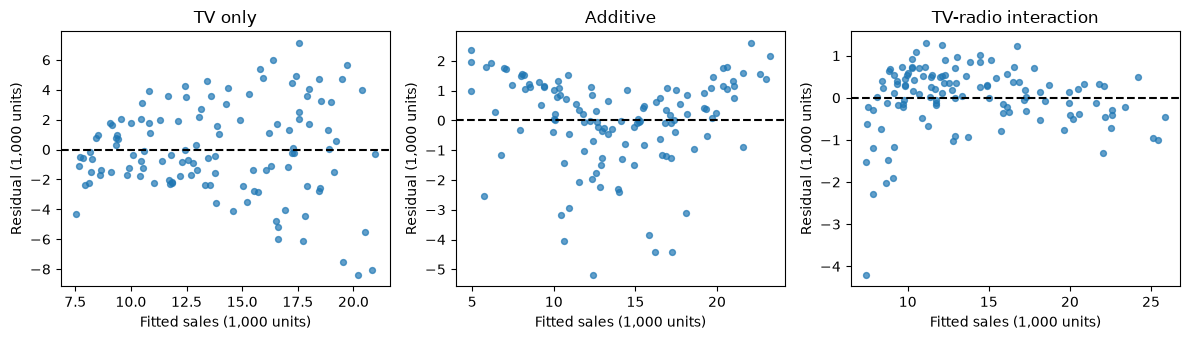

Validation RMSE for the frozen candidate: 1.3836


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, (name, model) in zip(axes, fitted_models.items()):
    fitted = model.predict(train[candidates[name]])
    residual = train["sales"].to_numpy() - fitted
    ax.scatter(fitted, residual, s=18, alpha=0.7)
    ax.axhline(0, color="black", linestyle="--")
    ax.set(title=name, xlabel="Fitted sales (1,000 units)", ylabel="Residual (1,000 units)")
plt.tight_layout()
plt.show()

def candidate_prediction(name, frame):
    if name == "Mean baseline":
        return np.full(len(frame), baseline)
    return fitted_models[name].predict(frame[candidates[name]])

validation_prediction = candidate_prediction(selected_name, valid)
print("Validation RMSE for the frozen candidate:",
      round(np.sqrt(mean_squared_error(valid["sales"], validation_prediction)), 4))

## 5. Final test evaluation

**Task:** Evaluate the chosen model once on the **40 test markets** that have not influenced
fitting or selection. Compare it with predicting the training mean for every market.
The code calls `.predict()` on the existing model; it does not fit anything on the test rows.

For this section, let $n=40$, $y_i$ be the observed test sales, and $\hat y_i$ the predicted test sales.
The table reports three complementary measures:

| Measure | Formula | Interpretation |
| --- | --- | --- |
| Mean absolute error (MAE) | $\frac{1}{n}\sum_{i=1}^n\lvert y_i-\hat y_i\rvert$ | Average absolute prediction error; lower is better. |
| Root mean squared error (RMSE) | $\sqrt{\frac{1}{n}\sum_{i=1}^n(y_i-\hat y_i)^2}$ | Weights larger errors more heavily than MAE; lower is better. |
| Coefficient of determination ($R^2$) | $1-\frac{\sum_{i=1}^n(y_i-\hat y_i)^2}{\sum_{i=1}^n(y_i-\bar y_{\mathrm{test}})^2}$ | Compares squared error with the variation of observed test sales; higher is better. |

MAE and RMSE are in **thousands of sales units**. For example, MAE $=0.65$ means predictions
are off by about 650 units on average in absolute value. $R^2$ has no units: 1 means perfect
predictions, 0 means the same squared error as always predicting the test-set mean, and a
negative value means worse squared error than that reference. It is not a percentage of
predictions that are “correct.” The test sales here have nonzero variance, so the denominator is nonzero.

**Two different means appear here:** the baseline actually predicts the **training mean**, which
is available before seeing any test targets. The **test mean** $\bar y_{\mathrm{test}}$ appears only
in the definition of the evaluation metric $R^2$; we do not use it to make predictions.
Consequently, the training-mean baseline can have a slightly negative test $R^2$.

In the saved results, the selected interaction model has MAE about $0.650$ and RMSE about
$0.853$ thousand units, compared with baseline RMSE about $5.653$. Its $R^2\approx0.977$
means its squared error is about 2.3% of the test-mean reference error on these 40 markets.
This indicates a substantial improvement over a constant prediction on this test split.

The table is a final assessment, not a menu for choosing another model. Changing the model
after inspecting these test results would make these rows part of model development;
a further independent evaluation would then be needed. The result also describes markets
similar to this sample, rather than guaranteeing the same error for all future markets.

**Check your understanding:** Why can the training-mean baseline have negative $R^2$,
even though a mean is used as the reference in the formula?

In [5]:
rows = []
for name in dict.fromkeys(["Mean baseline", selected_name]):
    prediction = candidate_prediction(name, test)
    rows.append({"model": name,
                 "MAE (1,000 units)": mean_absolute_error(test["sales"], prediction),
                 "RMSE (1,000 units)": np.sqrt(mean_squared_error(test["sales"], prediction)),
                 "R squared": r2_score(test["sales"], prediction)})
test_results = pd.DataFrame(rows).set_index("model")
display(test_results.round(4))

,"MAE (1,000 units)","RMSE (1,000 units)",R squared
model,,,
Mean baseline,4.6325,5.6526,-0.0176
TV-radio interaction,0.6501,0.8531,0.9768


## Interpret the results

- Does the interaction reduce CV error, and is that improvement reflected on the frozen test set?
- How does the modeled TV association change between radio budgets 0 and 30? Keep units explicit.
- Do residuals still suggest relationships the candidates do not capture?
- Only 120 markets fit the final model. Coefficients need not match the book's full-data estimates.
- A random split of these 200 markets estimates performance under a similar-market sampling view.
  It does not establish performance for a new time period or a different market population.
- Spending was not randomized here. A fitted coefficient is not automatically the effect of an intervention.

**In the saved run:** CV selects the TV/radio interaction. Test RMSE is about 0.853
thousand sales units, compared with 5.653 for the training-mean baseline. The modeled
change for an extra \$1,000 of TV is about 18.6 sales units at radio budget zero and
50.9 units at a radio budget of \$30,000. These are fitted associations in this dataset.